## Resume / Candidate Screening System

## Setup and Configuration

In [1]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('omw-1.4',      quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

DATA_PATH  = r'C:\Users\vinnu\Downloads\monster_com-job_sample.csv'
OUTPUT_DIR = r'C:\Users\vinnu\Downloads\FUTURE_ML_03\outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Setup Done')

Setup Done


## Load and Explore Job Postings

In [2]:
df = pd.read_csv(DATA_PATH, encoding='latin-1')

print('DATASET OVERVIEW')
print('=' * 55)
print(f'Total job postings : {len(df):,}')
print(f'Columns            : {df.shape[1]}')
print(f'Column names       : {df.columns.tolist()}')
print(f'Missing values     : {df.isnull().sum().sum()}')
print()
print('Top 10 Job Sectors:')
if 'sector' in df.columns:
    print(df['sector'].value_counts().head(10))
elif 'job_type' in df.columns:
    print(df['job_type'].value_counts().head(10))

df.head(3)

DATASET OVERVIEW
Total job postings : 22,000
Columns            : 14
Column names       : ['country', 'country_code', 'date_added', 'has_expired', 'job_board', 'job_description', 'job_title', 'job_type', 'location', 'organization', 'page_url', 'salary', 'sector', 'uniq_id']
Missing values     : 54121

Top 10 Job Sectors:
sector
Experienced (Non-Manager)                4594
Medical/Health                           1254
Entry Level                              1172
Sales/Retail/Business Development         938
Manager (Manager/Supervisor of Staff)     900
IT/Software Development                   861
Project/Program Management                790
Accounting/Finance/Insurance              742
Food Services/Hospitality                 633
Installation/Maintenance/Repair           574
Name: count, dtype: int64


,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
0,United States of America,US,NaN,No,jobs.monster.com,TeamSoft is seeing an IT Support Specialist to...,IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702",NaN,http://jobview.monster.com/it-support-technici...,NaN,IT/Software Development,11d599f229a80023d2f40e7c52cd941e
1,United States of America,US,NaN,No,jobs.monster.com,The Wisconsin State Journal is seeking a flexi...,Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-e...,NaN,NaN,e4cbb126dabf22159aff90223243ff2a
2,United States of America,US,NaN,No,jobs.monster.com,Report this job About the Job DePuy Synthes Co...,Johnson & Johnson Family of Companies Job Appl...,"Full Time, Employee",DePuy Synthes Companies is a member of Johnson...,Personal and Household Services,http://jobview.monster.com/senior-training-lea...,NaN,NaN,839106b353877fa3d896ffb9c1fe01c0


## Text Preprocessing and Skill Extraction

In [3]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

SKILLS_DICT = [

    'python','java','javascript','sql','r','c++','c#','php','ruby','scala',
    'typescript','swift','kotlin','golang','rust','matlab','perl','bash',

    'machine learning','deep learning','neural network','nlp','computer vision',
    'tensorflow','pytorch','keras','scikit-learn','pandas','numpy','matplotlib',
    'tableau','power bi','excel','spark','hadoop','hive','kafka',

    'html','css','react','angular','vue','nodejs','django','flask','spring',
    'aws','azure','gcp','docker','kubernetes','git','linux','rest api',

    'mysql','postgresql','mongodb','redis','oracle','sqlite','elasticsearch',

    'communication','leadership','teamwork','problem solving','analytical',
    'project management','agile','scrum','time management','critical thinking',

    'statistics','mathematics','data analysis','data visualization',
    'business intelligence','etl','data pipeline','feature engineering',
    'model deployment','a/b testing','hypothesis testing'
]

def clean_text(text):
    if pd.isna(text): return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s/]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def extract_skills(text):
    text_lower = clean_text(text)
    found = [skill for skill in SKILLS_DICT if skill in text_lower]
    return list(set(found))

desc_col = None
for col in ['job_description', 'description', 'body', 'summary', 'details', 'job_summary']:
    if col in df.columns:
        desc_col = col
        break
if desc_col is None:
    desc_col = df.columns[-1]

print(f'Using column: {desc_col} for job descriptions')

df['clean_desc']     = df[desc_col].apply(clean_text)
df['skills_found']   = df[desc_col].apply(extract_skills)
df['skill_count']    = df['skills_found'].apply(len)
df['desc_length']    = df['clean_desc'].apply(len)

print(f'Skills extracted from {len(df):,} job postings')
print(f'Average skills per posting: {df["skill_count"].mean():.1f}')

Using column: job_description for job descriptions
Skills extracted from 22,000 job postings
Average skills per posting: 2.9


## Sample Candidate Resumes

In [4]:
candidates = [
    {
        'name': 'Alice Johnson',
        'resume': '''
        Experienced Data Scientist with 5 years in machine learning and AI.
        Proficient in Python, TensorFlow, PyTorch, scikit-learn, pandas, numpy.
        Strong background in SQL, PostgreSQL, MongoDB and data pipeline development.
        Experience with AWS, Docker, Kubernetes for model deployment.
        Skilled in data visualization using Tableau and Matplotlib.
        Strong communication and leadership skills. Agile and Scrum practitioner.
        Statistics and mathematics expertise with hypothesis testing and A/B testing.
        '''
    },
    {
        'name': 'Bob Smith',
        'resume': '''
        Software Engineer with 3 years experience in web development.
        Proficient in JavaScript, React, Angular, NodeJS, HTML, CSS.
        Experience with Python, Django, Flask for backend development.
        Familiar with MySQL, Redis and REST API development.
        Used Git for version control and Docker for containerization.
        Good teamwork and communication skills.
        '''
    },
    {
        'name': 'Carol White',
        'resume': '''
        Junior Data Analyst with 1 year experience.
        Knowledge of Python, pandas, numpy and matplotlib.
        Basic SQL and Excel skills for data analysis.
        Familiar with machine learning concepts and scikit-learn.
        Strong analytical and problem solving skills.
        Good time management and critical thinking.
        '''
    },
    {
        'name': 'David Lee',
        'resume': '''
        Cloud Engineer with 4 years experience in AWS and Azure.
        Expert in Docker, Kubernetes, Linux and Bash scripting.
        Proficient in Python, Go and Scala for automation.
        Experience with Kafka, Spark, Hadoop for big data pipelines.
        Strong project management and leadership skills.
        Agile practitioner with excellent communication.
        '''
    },
    {
        'name': 'Emma Davis',
        'resume': '''
        Machine Learning Engineer with 6 years experience.
        Expert in Python, TensorFlow, Keras, PyTorch and deep learning.
        Strong NLP and computer vision background.
        Proficient in feature engineering, model deployment and A/B testing.
        Experience with AWS, GCP, Spark and Elasticsearch.
        Excellent leadership, communication and teamwork skills.
        Statistics and mathematics expertise.
        '''
    },
    {
        'name': 'Frank Wilson',
        'resume': '''
        Fresh graduate with knowledge of Java, Python and SQL.
        Basic understanding of machine learning and data analysis.
        Familiar with HTML, CSS and JavaScript.
        Good communication skills and eager to learn.
        '''
    },
    {
        'name': 'Grace Kim',
        'resume': '''
        Business Intelligence Analyst with 3 years experience.
        Expert in Tableau, Power BI and Excel for data visualization.
        Proficient in SQL, MySQL, PostgreSQL and ETL processes.
        Strong business intelligence and data pipeline experience.
        Excellent analytical and critical thinking skills.
        Good project management and agile experience.
        '''
    },
    {
        'name': 'Henry Brown',
        'resume': '''
        Full Stack Developer with 5 years experience.
        Expert in React, Angular, Vue, NodeJS, JavaScript, TypeScript.
        Backend experience with Python, Django, Spring, Java.
        Database skills in MySQL, MongoDB, Redis, PostgreSQL.
        DevOps experience with Docker, Git, AWS and REST API.
        Strong teamwork, communication and scrum skills.
        '''
    }
]

candidates_df = pd.DataFrame(candidates)
candidates_df['clean_resume'] = candidates_df['resume'].apply(clean_text)
candidates_df['resume_skills'] = candidates_df['resume'].apply(extract_skills)
candidates_df['skill_count']   = candidates_df['resume_skills'].apply(len)

print('CANDIDATE PROFILES')
print('=' * 55)
for _, row in candidates_df.iterrows():
    print(f"{row['name']:<20} Skills: {row['skill_count']} | {', '.join(row['resume_skills'][:5])}...")
print(f'\n {len(candidates_df)} candidates loaded')

CANDIDATE PROFILES
Alice Johnson        Skills: 26 | matplotlib, aws, scrum, tensorflow, kubernetes...
Bob Smith            Skills: 19 | git, mysql, django, r, java...
Carol White          Skills: 13 | r, matplotlib, numpy, data analysis, analytical...
David Lee            Skills: 18 | r, leadership, agile, aws, data pipeline...
Emma Davis           Skills: 22 | aws, tensorflow, feature engineering, spark, keras...
Frank Wilson         Skills: 10 | r, css, data analysis, html, java...
Grace Kim            Skills: 15 | r, agile, business intelligence, data pipeline, analytical...
Henry Brown          Skills: 23 | spring, git, vue, aws, scrum...

 8 candidates loaded


## Job Role Selection and Screening

In [5]:
def screen_candidates(job_description, job_title='Selected Role', top_n=5):
   
    required_skills = extract_skills(job_description)
    clean_job       = clean_text(job_description)

    all_texts  = [clean_job] + candidates_df['clean_resume'].tolist()
    vectorizer = TfidfVectorizer(ngram_range=(1,2), stop_words='english')
    tfidf_mat  = vectorizer.fit_transform(all_texts)
    similarities = cosine_similarity(tfidf_mat[0:1], tfidf_mat[1:]).flatten()

    results = []
    for i, (_, cand) in enumerate(candidates_df.iterrows()):
        cand_skills    = set(cand['resume_skills'])
        req_skills_set = set(required_skills)
        matched        = cand_skills & req_skills_set
        missing        = req_skills_set - cand_skills
        skill_score    = len(matched) / len(req_skills_set) * 100 if req_skills_set else 0
        final_score    = (similarities[i] * 50) + (skill_score * 0.5)
        results.append({
            'Rank':            0,
            'Candidate':       cand['name'],
            'Similarity':      round(similarities[i] * 100, 2),
            'Skill Match %':   round(skill_score, 2),
            'Final Score':     round(final_score, 2),
            'Matched Skills':  matched,
            'Missing Skills':  missing,
            'Total Skills':    cand['skill_count']
        })

    results_df = pd.DataFrame(results).sort_values('Final Score', ascending=False).reset_index(drop=True)
    results_df['Rank'] = range(1, len(results_df)+1)

    print(f'SCREENING RESULTS FOR: {job_title}')
    print('=' * 65)
    print(f'Required Skills: {required_skills}')
    print()
    print(f'{"Rank":<6}{"Candidate":<20}{"Similarity":<14}{"Skill Match":<14}{"Final Score"}')
    print('-' * 65)
    for _, row in results_df.iterrows():
        print(f"{row['Rank']:<6}{row['Candidate']:<20}{row['Similarity']:<14}{row['Skill Match %']:<14}{row['Final Score']}")

    return results_df, required_skills

sample_job = df[df['skill_count'] > 3].iloc[0]
desc_text  = sample_job[desc_col]
title_col  = 'title' if 'title' in df.columns else df.columns[0]
job_title  = str(sample_job[title_col])[:50]

results_df, req_skills = screen_candidates(desc_text, job_title)

SCREENING RESULTS FOR: United States of America
Required Skills: ['r', 'leadership', 'agile', 'aws', 'scala', 'excel', 'communication', 'project management']

Rank  Candidate           Similarity    Skill Match   Final Score
-----------------------------------------------------------------
1     David Lee           4.05          100.0         52.02
2     Emma Davis          1.97          62.5          32.24
3     Alice Johnson       1.84          62.5          32.17
4     Grace Kim           5.63          50.0          27.82
5     Henry Brown         1.73          37.5          19.61
6     Carol White         3.35          25.0          14.18
7     Bob Smith           2.45          25.0          13.72
8     Frank Wilson        2.21          25.0          13.61


## Skill Gap Analysis

In [6]:
print('SKILL GAP ANALYSIS')
print('=' * 65)
for _, row in results_df.iterrows():
    print(f"\nRank {row['Rank']} — {row['Candidate']}")
    print(f"   Final Score    : {row['Final Score']}")
    print(f"   Skill Match    : {row['Skill Match %']}%")
    if row['Matched Skills']:
        print(f"   Matched Skills : {', '.join(sorted(row['Matched Skills']))}")
    else:
        print(f"   Matched Skills : None")
    if row['Missing Skills']:
        print(f"   Missing Skills : {', '.join(sorted(row['Missing Skills']))}")
    else:
        print(f"   Missing Skills : None — Perfect Match!")

SKILL GAP ANALYSIS

Rank 1 — David Lee
   Final Score    : 52.02
   Skill Match    : 100.0%
   Matched Skills : agile, aws, communication, excel, leadership, project management, r, scala
   Missing Skills : None — Perfect Match!

Rank 2 — Emma Davis
   Final Score    : 32.24
   Skill Match    : 62.5%
   Matched Skills : aws, communication, excel, leadership, r
   Missing Skills : agile, project management, scala

Rank 3 — Alice Johnson
   Final Score    : 32.17
   Skill Match    : 62.5%
   Matched Skills : agile, aws, communication, leadership, r
   Missing Skills : excel, project management, scala

Rank 4 — Grace Kim
   Final Score    : 27.82
   Skill Match    : 50.0%
   Matched Skills : agile, excel, project management, r
   Missing Skills : aws, communication, leadership, scala

Rank 5 — Henry Brown
   Final Score    : 19.61
   Skill Match    : 37.5%
   Matched Skills : aws, communication, r
   Missing Skills : agile, excel, leadership, project management, scala

Rank 6 — Carol Whit

## Visualizations

### Visualization 1: Job Market Overview

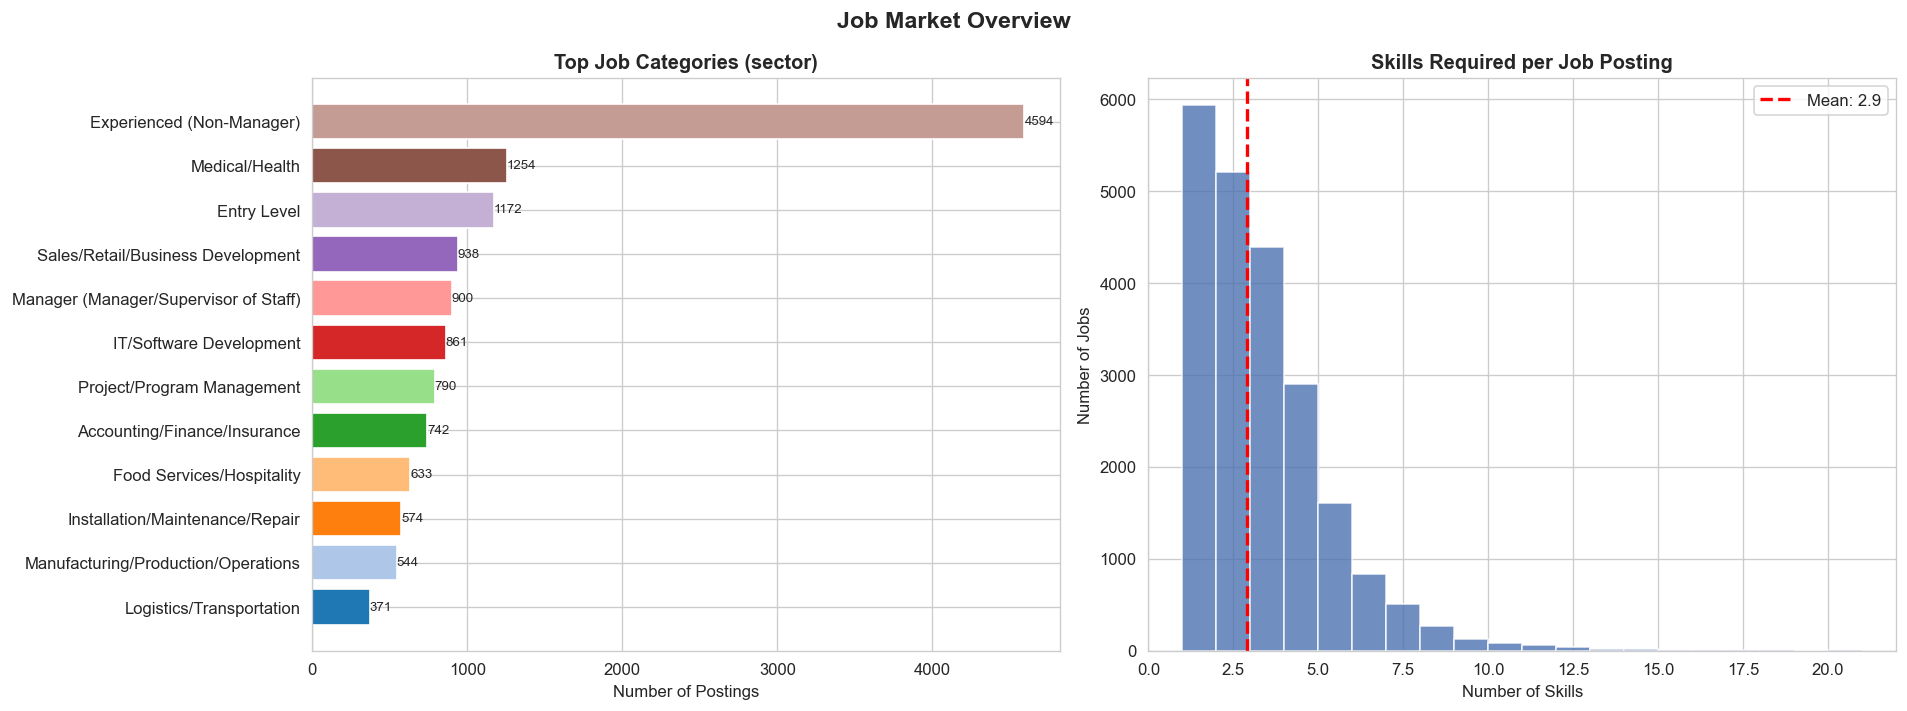

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_col = 'sector' if 'sector' in df.columns else ('job_type' if 'job_type' in df.columns else df.columns[2])
top_cats = df[cat_col].value_counts().head(12)
axes[0].barh(top_cats.index[::-1], top_cats.values[::-1],
             color=plt.cm.tab20.colors[:len(top_cats)])
axes[0].set_title(f'Top Job Categories ({cat_col})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Postings')
for i, v in enumerate(top_cats.values[::-1]):
    axes[0].text(v + 0.5, i, str(v), va='center', fontsize=8)

axes[1].hist(df['skill_count'], bins=20, color='#4C72B0', alpha=0.8, edgecolor='white')
axes[1].axvline(df['skill_count'].mean(), color='red', linestyle='--',
                lw=2, label=f'Mean: {df["skill_count"].mean():.1f}')
axes[1].set_title('Skills Required per Job Posting', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Skills')
axes[1].set_ylabel('Number of Jobs')
axes[1].legend()

plt.suptitle('Job Market Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization 2: Most In-Demand Skills

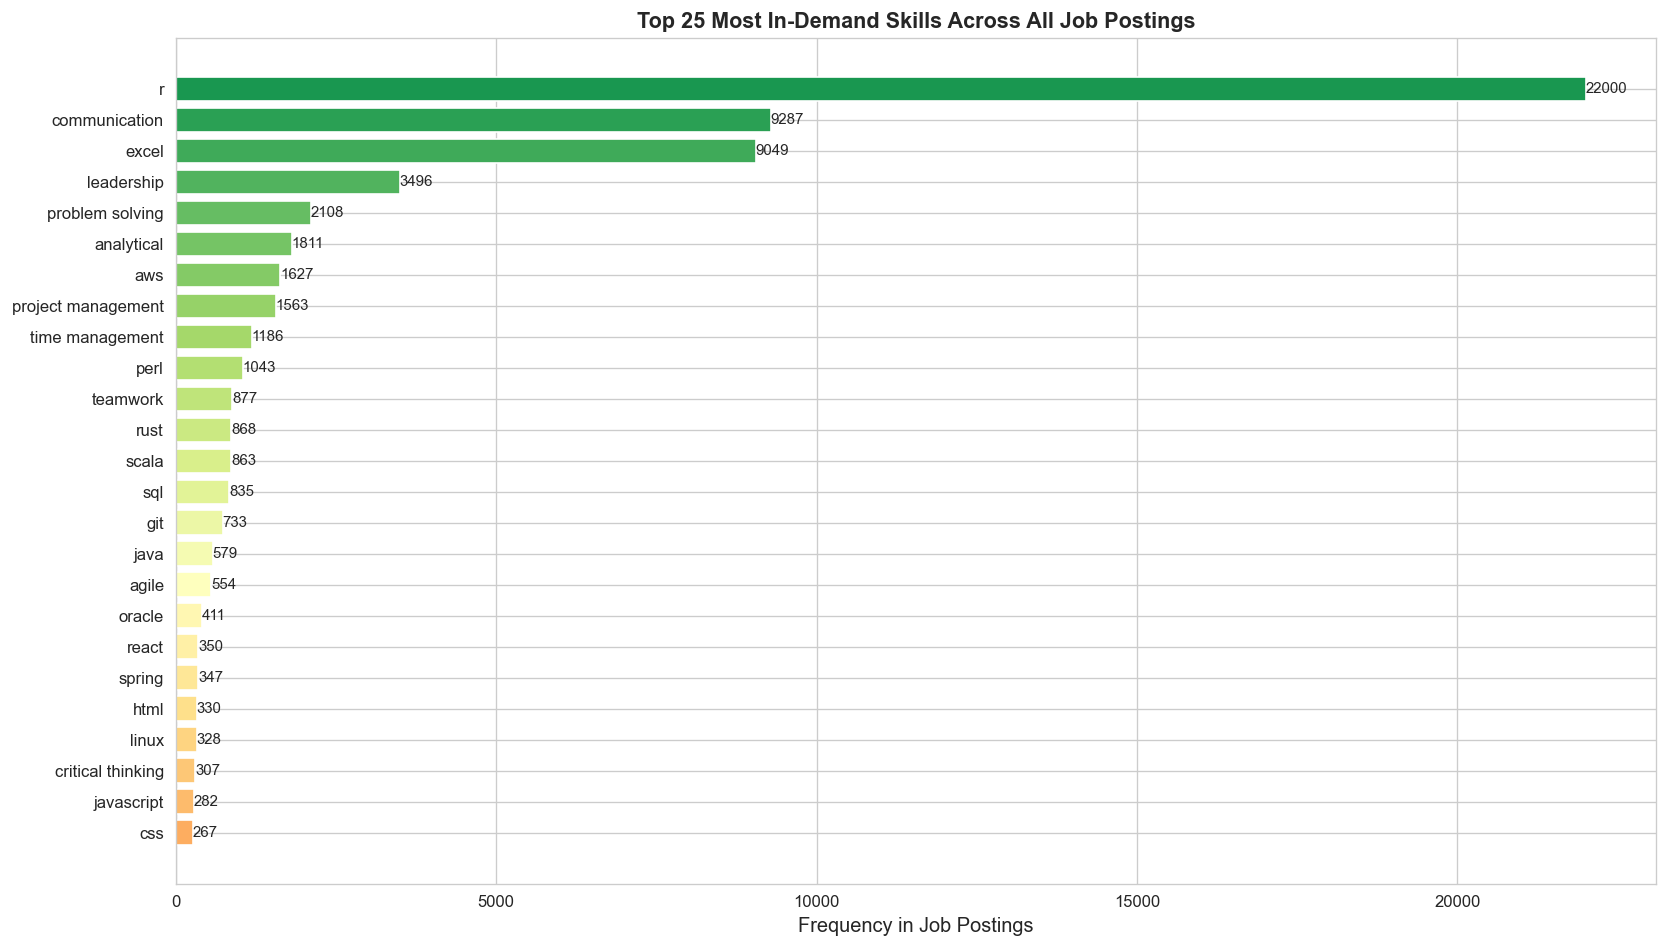

In [8]:
all_skills = [skill for skills in df['skills_found'] for skill in skills]
skill_freq = Counter(all_skills).most_common(25)
skill_names = [s[0] for s in skill_freq]
skill_counts = [s[1] for s in skill_freq]

fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(skill_names)))
bars = ax.barh(skill_names[::-1], skill_counts[::-1], color=colors)
for bar, cnt in zip(bars, skill_counts[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(cnt), va='center', fontsize=9)
ax.set_xlabel('Frequency in Job Postings', fontsize=12)
ax.set_title('Top 25 Most In-Demand Skills Across All Job Postings',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization 3: Candidate Ranking Dashboard

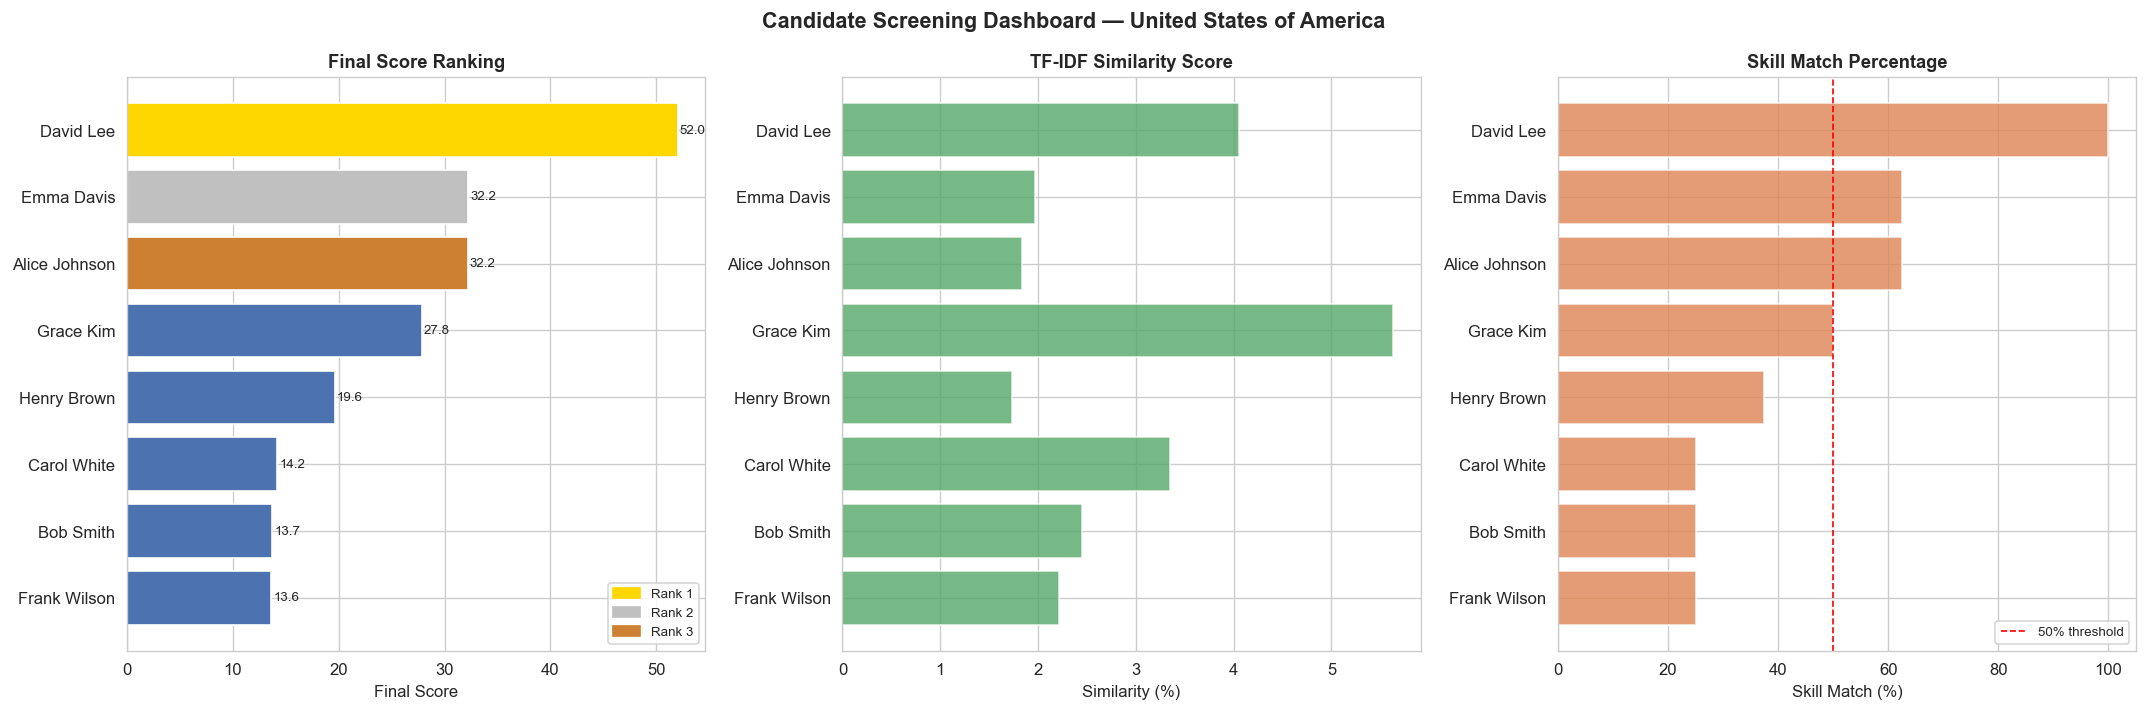

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors_rank = ['#FFD700' if i==0 else '#C0C0C0' if i==1 else '#CD7F32' if i==2
               else '#4C72B0' for i in range(len(results_df))]
bars = axes[0].barh(results_df['Candidate'][::-1], results_df['Final Score'][::-1],
                    color=colors_rank[::-1])
axes[0].set_title('Final Score Ranking', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Final Score')
for bar, v in zip(bars, results_df['Final Score'][::-1]):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}', va='center', fontsize=8)

axes[1].barh(results_df['Candidate'][::-1], results_df['Similarity'][::-1],
             color='#55A868', alpha=0.8)
axes[1].set_title('TF-IDF Similarity Score', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Similarity (%)')

axes[2].barh(results_df['Candidate'][::-1], results_df['Skill Match %'][::-1],
             color='#DD8452', alpha=0.8)
axes[2].set_title('Skill Match Percentage', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Skill Match (%)')
axes[2].axvline(50, color='red', linestyle='--', lw=1, label='50% threshold')
axes[2].legend(fontsize=8)

gold   = mpatches.Patch(color='#FFD700', label='Rank 1')
silver = mpatches.Patch(color='#C0C0C0', label='Rank 2')
bronze = mpatches.Patch(color='#CD7F32', label='Rank 3')
axes[0].legend(handles=[gold, silver, bronze], fontsize=8)

plt.suptitle(f'Candidate Screening Dashboard — {job_title[:40]}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Visualization 4: Skill Gap Heatmap

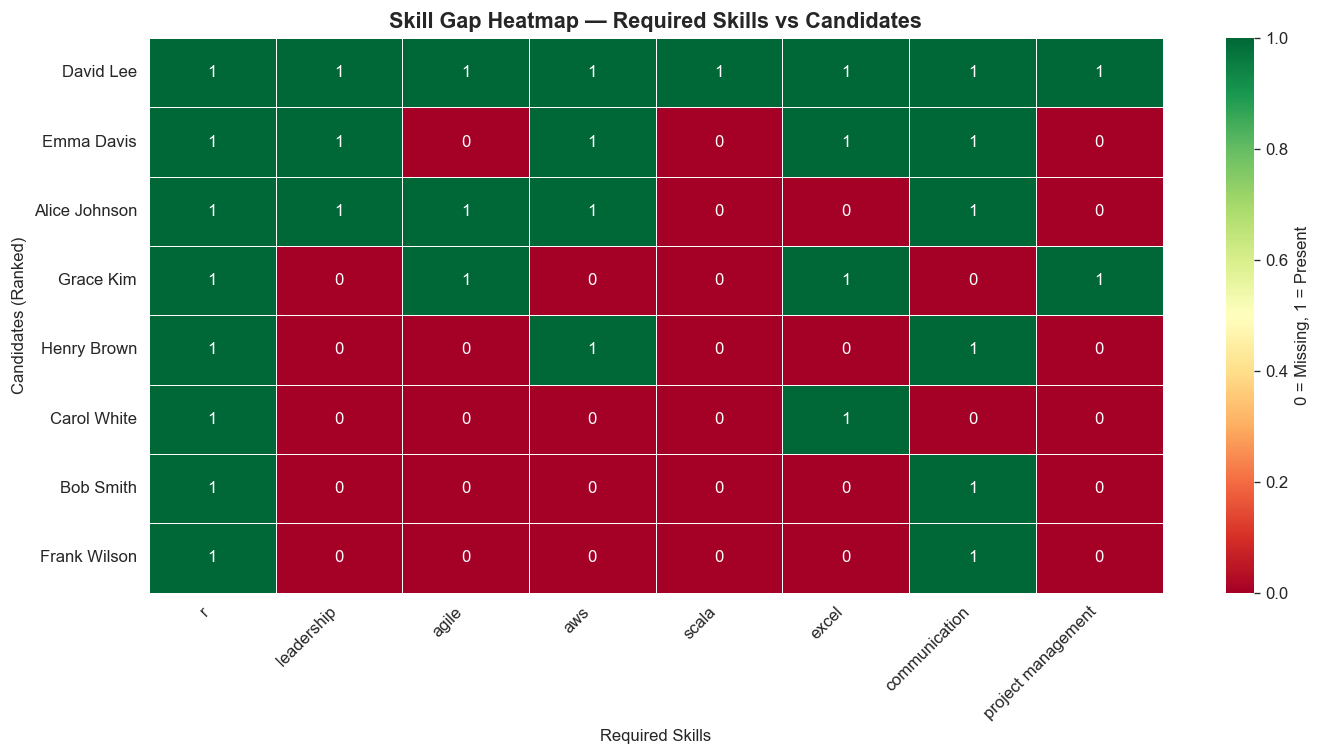

In [10]:
if req_skills:
    skill_matrix = []
    for _, row in results_df.iterrows():
        cand_name = row['Candidate']
        cand_row  = candidates_df[candidates_df['name']==cand_name].iloc[0]
        skill_row = [1 if skill in cand_row['resume_skills'] else 0 for skill in req_skills]
        skill_matrix.append(skill_row)

    skill_matrix_df = pd.DataFrame(
        skill_matrix,
        index=results_df['Candidate'],
        columns=req_skills
    )

    fig, ax = plt.subplots(figsize=(max(10, len(req_skills)*1.5), max(6, len(results_df)*0.8)))
    sns.heatmap(skill_matrix_df, annot=True, fmt='d', cmap='RdYlGn',
                linewidths=0.5, ax=ax, vmin=0, vmax=1,
                cbar_kws={'label': '0 = Missing, 1 = Present'})
    ax.set_title('Skill Gap Heatmap — Required Skills vs Candidates',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Required Skills')
    ax.set_ylabel('Candidates (Ranked)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No specific skills extracted from this job posting.')

### Visualization 5: Candidate Skill Profile Comparison

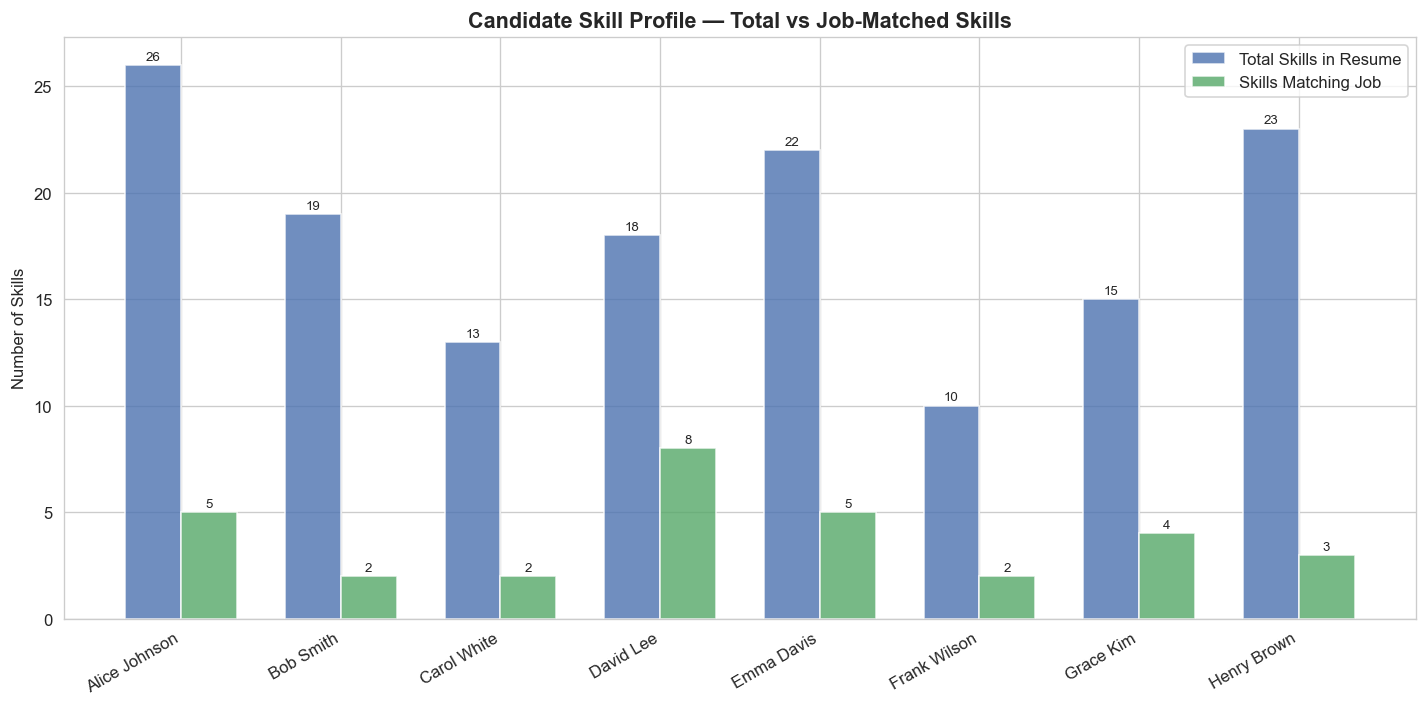

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

x     = np.arange(len(candidates_df))
width = 0.35

bars1 = ax.bar(x - width/2, candidates_df['skill_count'],
               width, label='Total Skills in Resume', color='#4C72B0', alpha=0.8)

matched_counts = []
for _, cand in candidates_df.iterrows():
    matched = len(set(cand['resume_skills']) & set(req_skills)) if req_skills else 0
    matched_counts.append(matched)

bars2 = ax.bar(x + width/2, matched_counts,
               width, label='Skills Matching Job', color='#55A868', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(candidates_df['name'], rotation=30, ha='right')
ax.set_ylabel('Number of Skills')
ax.set_title('Candidate Skill Profile — Total vs Job-Matched Skills',
             fontsize=13, fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Visualization 6: Score Breakdown per Candidate

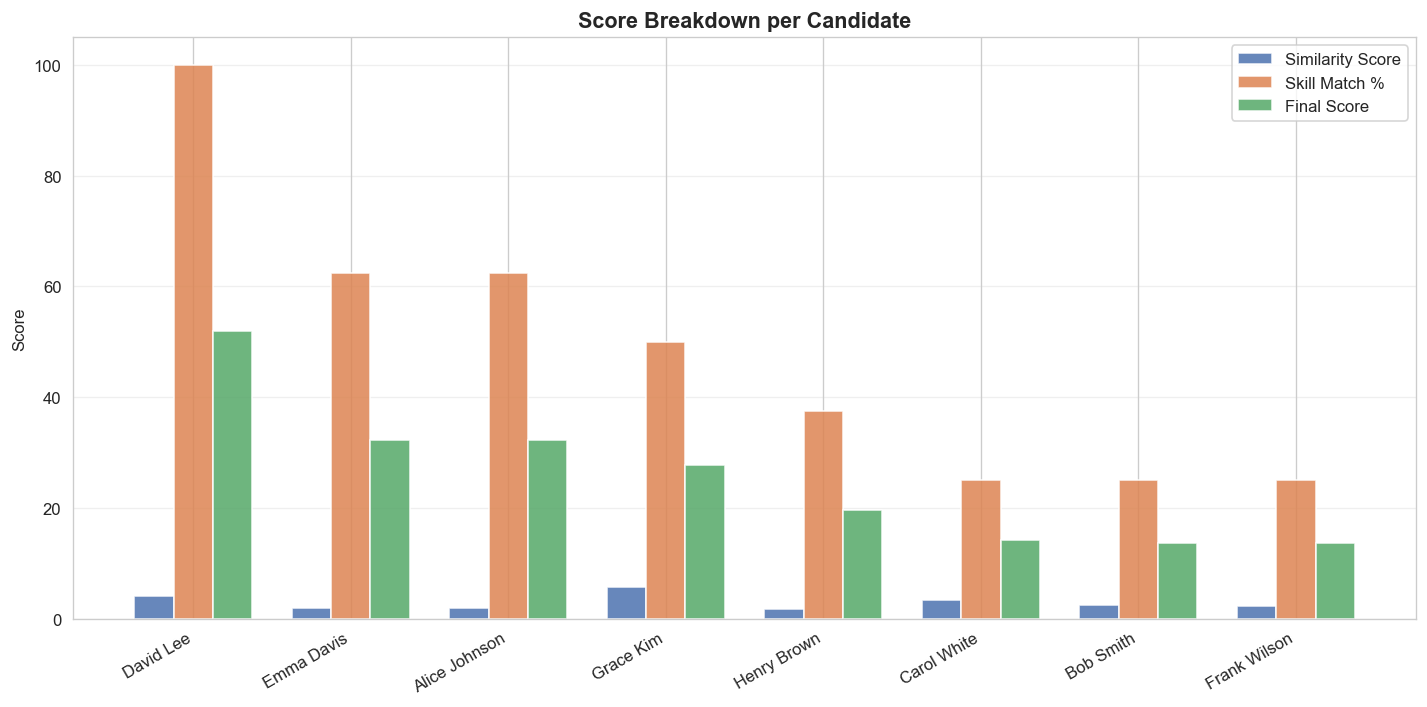

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

x     = np.arange(len(results_df))
width = 0.25

b1 = ax.bar(x - width, results_df['Similarity'],   width, label='Similarity Score', color='#4C72B0', alpha=0.85)
b2 = ax.bar(x,         results_df['Skill Match %'], width, label='Skill Match %',   color='#DD8452', alpha=0.85)
b3 = ax.bar(x + width, results_df['Final Score'],   width, label='Final Score',     color='#55A868', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Candidate'], rotation=30, ha='right')
ax.set_ylabel('Score')
ax.set_title('Score Breakdown per Candidate', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Screen Against Multiple Job Roles

In [13]:
top_jobs = df[df['skill_count'] > 3].head(3)

print('MULTI-ROLE SCREENING REPORT')
print('=' * 65)

for i, (_, job) in enumerate(top_jobs.iterrows()):
    title = str(job[title_col])[:40]
    print(f'\nJob Role {i+1}: {title}')
    res, _ = screen_candidates(job[desc_col], title)
    top3   = res.head(3)
    print(f'Top 3 Candidates:')
    for _, r in top3.iterrows():
        print(f'   {r["Rank"]}. {r["Candidate"]} — Score: {r["Final Score"]}')

MULTI-ROLE SCREENING REPORT

Job Role 1: United States of America
SCREENING RESULTS FOR: United States of America
Required Skills: ['r', 'leadership', 'agile', 'aws', 'scala', 'excel', 'communication', 'project management']

Rank  Candidate           Similarity    Skill Match   Final Score
-----------------------------------------------------------------
1     David Lee           4.05          100.0         52.02
2     Emma Davis          1.97          62.5          32.24
3     Alice Johnson       1.84          62.5          32.17
4     Grace Kim           5.63          50.0          27.82
5     Henry Brown         1.73          37.5          19.61
6     Carol White         3.35          25.0          14.18
7     Bob Smith           2.45          25.0          13.72
8     Frank Wilson        2.21          25.0          13.61
Top 3 Candidates:
   1. David Lee — Score: 52.02
   2. Emma Davis — Score: 32.24
   3. Alice Johnson — Score: 32.17

Job Role 2: United States of America
SCREENING

## Final Business Report

In [14]:
print('=' * 65)
print('  RESUME SCREENING SYSTEM — FINAL BUSINESS REPORT')
print('=' * 65)

print('\n1. DATASET SUMMARY')
print(f'   Job postings analyzed  : {len(df):,}')
print(f'   Unique job categories  : {df[cat_col].nunique()}')
print(f'   Avg skills per posting : {df["skill_count"].mean():.1f}')
print(f'   Total skills tracked   : {len(SKILLS_DICT)}')

print('\n2. CANDIDATE POOL')
print(f'   Total candidates       : {len(candidates_df)}')
print(f'   Avg skills per resume  : {candidates_df["skill_count"].mean():.1f}')
print(f'   Most skilled           : {candidates_df.loc[candidates_df["skill_count"].idxmax(), "name"]} ({candidates_df["skill_count"].max()} skills)')

print('\n3. SCREENING RESULTS (Last Job Role)')
print(f'   Job Role               : {job_title[:40]}')
print(f'   Required Skills        : {len(req_skills)}')
for _, row in results_df.head(3).iterrows():
    print(f'   Rank {row["Rank"]}: {row["Candidate"]:<20} Score: {row["Final Score"]}')

print('\n4. HOW SCORING WORKS')
print('   Final Score = (TF-IDF Similarity x 50) + (Skill Match % x 0.5)')
print('   TF-IDF Similarity : Measures overall text relevance (0-100)')
print('   Skill Match %     : Percentage of required skills present in resume')

print('\n5. BUSINESS VALUE')
print('   - Screens hundreds of resumes in seconds')
print('   - Removes bias from initial screening')
print('   - Shows exactly which skills candidates lack')
print('   - Ranks candidates objectively by role fit')
print('   - Saves recruiter hours per job posting')
print('=' * 65)

  RESUME SCREENING SYSTEM — FINAL BUSINESS REPORT

1. DATASET SUMMARY
   Job postings analyzed  : 22,000
   Unique job categories  : 163
   Avg skills per posting : 2.9
   Total skills tracked   : 82

2. CANDIDATE POOL
   Total candidates       : 8
   Avg skills per resume  : 18.2
   Most skilled           : Alice Johnson (26 skills)

3. SCREENING RESULTS (Last Job Role)
   Job Role               : United States of America
   Required Skills        : 8
   Rank 1: David Lee            Score: 52.02
   Rank 2: Emma Davis           Score: 32.24
   Rank 3: Alice Johnson        Score: 32.17

4. HOW SCORING WORKS
   Final Score = (TF-IDF Similarity x 50) + (Skill Match % x 0.5)
   TF-IDF Similarity : Measures overall text relevance (0-100)
   Skill Match %     : Percentage of required skills present in resume

5. BUSINESS VALUE
   - Screens hundreds of resumes in seconds
   - Removes bias from initial screening
   - Shows exactly which skills candidates lack
   - Ranks candidates objectively 